In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

avaliacoes = pd.read_csv('avaliacoes.csv')
clientes = pd.read_csv('clientes.csv')
itens_pedidos = pd.read_csv('itens_pedido.csv')
pedidos = pd.read_csv('pedidos.csv')
produtos = pd.read_csv('produtos.csv')
tickets_suporte = pd.read_csv('tickets_suporte.csv')

In [2]:
# aqui eu converti todas as colunas de data para o formato correto
avaliacoes['data_avaliacao'] = pd.to_datetime(avaliacoes['data_avaliacao'])
clientes['data_cadastro'] = pd.to_datetime(clientes['data_cadastro'])
pedidos['data_pedido'] = pd.to_datetime(pedidos['data_pedido'])
tickets_suporte['data_abertura'] = pd.to_datetime(tickets_suporte['data_abertura'])
tickets_suporte['data_resolucao'] = pd.to_datetime(tickets_suporte['data_resolucao'])

print("Datas convertidas com sucesso!")

Datas convertidas com sucesso!


In [3]:
# verifiquei dados nulos
relatorio_nulos = {
    "Pedidos sem Valor": pedidos['valor_total'].isnull().sum(),
    "Pedidos sem Status": pedidos['status'].isnull().sum(),
    "Clientes sem Segmento": clientes['segmento'].isnull().sum(),
    "Produtos sem Preço": produtos['preco_unitario'].isnull().sum()
}
# verifiquei duplicatas
duplicatas = {
    "IDs de Pedidos Duplicados": pedidos['id'].duplicated().sum(),
    "IDs de Clientes Duplicados": clientes['id'].duplicated().sum()
}
# verifiquei outliers/valores fora do padrao, como pedidos com valor 0 ou negativo
outliers_valor = pedidos[pedidos['valor_total'] <= 0]

print("--- Relatório de Qualidade de Dados ---")
for k, v in relatorio_nulos.items(): print(f"{k}: {v}")
for k, v in duplicatas.items(): print(f"{k}: {v}")
print(f"Pedidos com valor <= 0: {len(outliers_valor)}")

--- Relatório de Qualidade de Dados ---
Pedidos sem Valor: 79
Pedidos sem Status: 0
Clientes sem Segmento: 0
Produtos sem Preço: 0
IDs de Pedidos Duplicados: 0
IDs de Clientes Duplicados: 0
Pedidos com valor <= 0: 0


In [4]:
# como tinhamos 79 pedidos sem valor, dropei eles
pedidos.dropna(subset=['valor_total'], inplace=True)

In [5]:
clientes['canal_aquisicao'] = clientes['canal_aquisicao'].str.replace('orgÃ¢nico', 'organico').str.replace('orgnico', 'organico')

In [6]:
# verifiquei se todos os pedidos em 'itens_pedidos' existem na tabela 'pedidos'
itens_sem_pedido = itens_pedidos[~itens_pedidos['pedido_id'].isin(pedidos['id'])]
print(f"Itens de pedido sem cabeçalho (órfãos): {len(itens_sem_pedido)}")

# verifiquei se todos os clientes em 'pedidos' estão cadastrados em 'clientes'
pedidos_sem_cliente = pedidos[~pedidos['cliente_id'].isin(clientes['id'])]
print(f"Pedidos sem cadastro de cliente: {len(pedidos_sem_cliente)}")

Itens de pedido sem cabeçalho (órfãos): 189
Pedidos sem cadastro de cliente: 0


In [7]:
# chequei os precos e quantidades
precos_invalidos = itens_pedidos[itens_pedidos['preco_praticado'] <= 0]
print(f"Produtos com preço inválido: {len(precos_invalidos)}")

# chequei a cronologia das datas e fiz um merge temporario para validarr
df_validacao_datas = pd.merge(pedidos[['id', 'data_pedido']],
                               avaliacoes[['pedido_id', 'data_avaliacao']],
                               left_on='id', right_on='pedido_id')

datas_erradas = df_validacao_datas[df_validacao_datas['data_avaliacao'] < df_validacao_datas['data_pedido']]
print(f"Avaliações feitas antes do pedido: {len(datas_erradas)}")

Produtos com preço inválido: 0
Avaliações feitas antes do pedido: 0


In [8]:
# tambem aproveitei para corrigir o enconding (ex: orgÃ¢nico para orgânico) e padronizar as strings
def limpar_texto(txt):
    if isinstance(txt, str):
        return txt.encode('latin1').decode('utf-8', 'ignore').strip().lower()
    return txt

clientes['segmento'] = clientes['segmento'].apply(limpar_texto)
clientes['canal_aquisicao'] = clientes['canal_aquisicao'].apply(limpar_texto)
pedidos['status'] = pedidos['status'].apply(limpar_texto)
pedidos['canal_venda'] = pedidos['canal_venda'].apply(limpar_texto)
clientes.loc[clientes['canal_aquisicao'].str.contains('org', na=False), 'canal_aquisicao'] = 'organico'
clientes['canal_aquisicao'] = clientes['canal_aquisicao'].str.replace('indicao', 'indicacao')

Tabela da Questão 1:


,Status,Quantidade,Percentual (%)
0,entregue,9901,66.36
1,cancelado,2526,16.93
2,em_transito,1365,9.15
3,devolvido,1129,7.57


/tmp/ipykernel_3895/1381407848.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_status, x='Status', y='Quantidade', palette='viridis')


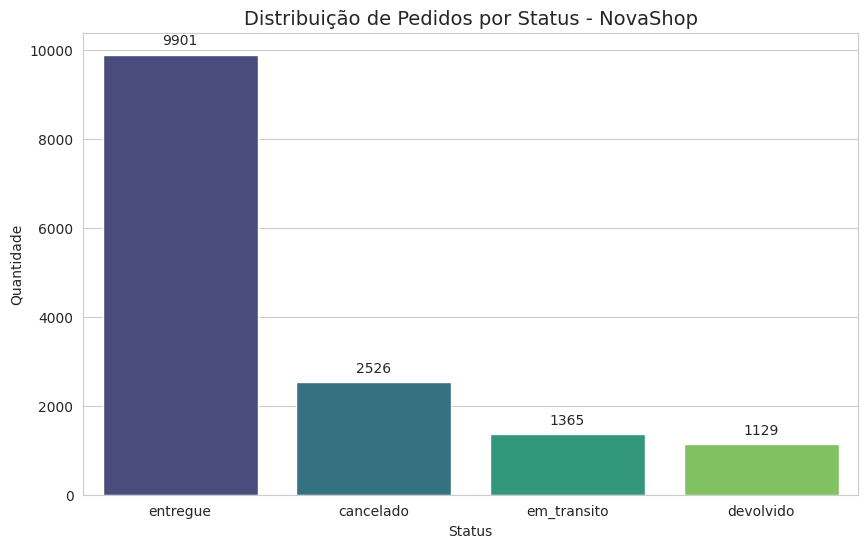

In [9]:
# tabela de freq.
df_status = pedidos['status'].value_counts().reset_index()
df_status.columns = ['Status', 'Quantidade']

# calculo do porcentual
df_status['Percentual (%)'] = (df_status['Quantidade'] / df_status['Quantidade'].sum() * 100).round(2)

print("Tabela da Questão 1:")
display(df_status)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_status, x='Status', y='Quantidade', palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Distribuição de Pedidos por Status - NovaShop', fontsize=14)
plt.show()

# Questão 1: Análise de Volume e Status de Pedidos

### **Principais Insights**

**Eficiência de Entrega:** Aproximadamente 66,36% dos pedidos foram concluídos com sucesso (Entregues). Embora seja a maioria, há uma margem significativa para otimização da jornada do cliente.

**Atenção aos Cancelamentos:** O índice de cancelamento é elevado (16,93%), representando quase 1 em cada 5 pedidos. Este dado acende um alerta sobre possíveis atritos no checkout, problemas de estoque ou tempo de entrega prometido.

**Logística Reversa:** Somando-se os pedidos cancelados e devolvidos, temos 24,5% da operação não convertida em receita final retida. Isso indica uma oportunidade de redução de custos operacionais e melhoria na experiência de pós-venda.

**Nota de Consistência (Questão 6):** Os dados foram padronizados para letras minúsculas e tratados contra erros de encoding antes da contagem, garantindo que variações de digitação não gerassem duplicidade nas categorias.

,nome,quantidade,receita_item
178,Tênis Esportivo 78,669,"R$ 2,017,790.51"
77,Equipamentos de Academia 83,609,"R$ 1,961,350.85"
128,Notebooks 4,589,"R$ 1,913,053.36"
152,Roupas Íntimas 48,651,"R$ 1,906,096.07"
95,Literatura 131,575,"R$ 1,880,745.06"
117,Material Escolar 142,609,"R$ 1,849,905.02"
88,Fraldas 145,590,"R$ 1,804,002.83"
19,Cadeirinhas 159,571,"R$ 1,794,833.09"
50,Chás 118,637,"R$ 1,765,601.55"
70,Câmeras 26,609,"R$ 1,738,445.85"


/tmp/ipykernel_3895/548878676.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_receita, y='nome', x='quantidade', palette='viridis')


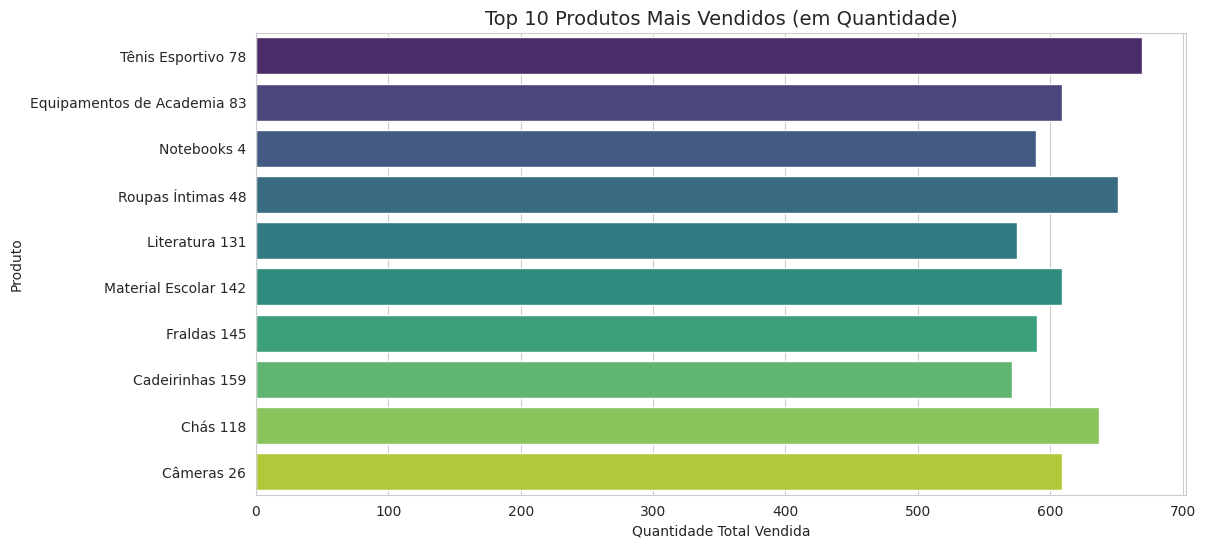

In [10]:
# uni itens com produtos para saber os nomes
df_itens_detalhado = pd.merge(itens_pedidos, produtos, left_on='produto_id', right_on='id', how='left')

# calculei a receita de cada linha através de quantidade * preco praticado
df_itens_detalhado['receita_item'] = df_itens_detalhado['quantidade'] * df_itens_detalhado['preco_praticado']

# agrupei por produto para somar quantidade e receita
ranking_produtos = df_itens_detalhado.groupby('nome').agg({
    'quantidade': 'sum',
    'receita_item': 'sum'
}).reset_index()


top_10_receita = ranking_produtos.sort_values(by='receita_item', ascending=False).head(10)
top_10_receita['receita_item'] = top_10_receita['receita_item'].map('R$ {:,.2f}'.format)
display(top_10_receita)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_receita, y='nome', x='quantidade', palette='viridis')
plt.title('Top 10 Produtos Mais Vendidos (em Quantidade)', fontsize=14)
plt.xlabel('Quantidade Total Vendida')
plt.ylabel('Produto')
plt.show()

# Questão 2: Análise de Performance de Produtos

A análise do Top 10 revela um equilíbrio entre categorias de alto giro (Fraldas, Chás) e produtos de maior valor agregado (Notebooks, Câmeras).

### **Principais Insights**

**Liderança Esportiva:** A categoria de Esportes e Fitness domina o topo do ranking, com Tênis e Equipamentos de Academia somando quase R$ 4 milhões em receita.

**Volume vs. Valor:** O item Roupas Íntimas 48 possui o segundo maior volume de vendas (651 unidades), mas ocupa a 4ª posição em receita, indicando um ticket médio menor comparado aos Notebooks.

**Mix de Consumo:** A presença de itens como Fraldas (7° posição) e Material Escolar (6° posição) no Top 10 sugere que a NovaShop possui uma base de clientes fiel para itens de necessidade recorrente.

Resultado do Teste T: p-valor = 0.0000000000
A diferença é estatisticamente significante.
Análise de Ticket Médio:


,Segmento,Ticket Médio,Qtd Pedidos,Desvio Padrão
0,b2b,7778.340413,3001,4152.138989
1,b2c,1264.719217,11920,713.953757



Resultado do Teste T: p-valor = 0.0000


/tmp/ipykernel_3895/7469628.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_vendas_segmento, x='segmento', y='valor_total', palette='Set2')


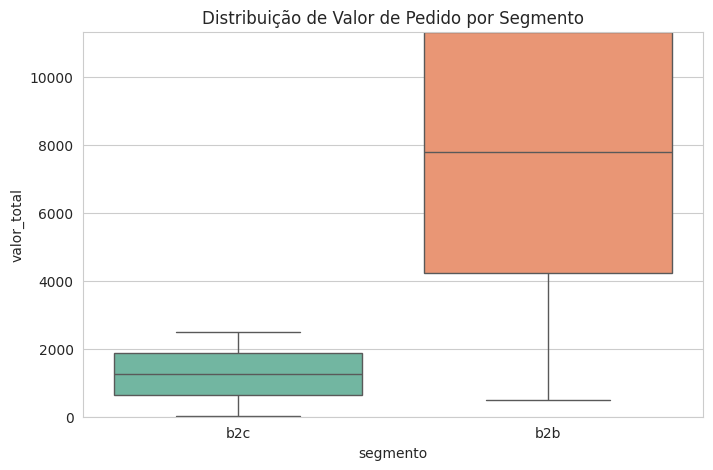

In [11]:
# uni pedidos com clientes para pegar o segmento e calculei o ticket medio por segmento
df_vendas_segmento = pd.merge(pedidos, clientes, left_on='cliente_id', right_on='id', how='left')
ticket_segmento = df_vendas_segmento.groupby('segmento')['valor_total'].agg(['mean', 'count', 'std']).reset_index()
ticket_segmento.columns = ['Segmento', 'Ticket Médio', 'Qtd Pedidos', 'Desvio Padrão']

# teste estatistico (t-test) para ver se a diferença é real ou acaso
#b2b_values = df_vendas_segmento[df_vendas_segmento['segmento'] == 'b2b']['valor_total']
#b2c_values = df_vendas_segmento[df_vendas_segmento['segmento'] == 'b2c']['valor_total']
b2b_values = df_vendas_segmento[df_vendas_segmento['segmento'] == 'b2b']['valor_total'].dropna()
b2c_values = df_vendas_segmento[df_vendas_segmento['segmento'] == 'b2c']['valor_total'].dropna()

t_stat, p_valor = stats.ttest_ind(b2b_values, b2c_values)
print(f"Resultado do Teste T: p-valor = {p_valor:.10f}")

if p_valor < 0.05:
    print("A diferença é estatisticamente significante.")
else:
    print("Não há evidências estatísticas de que as médias sejam diferentes.")

print("Análise de Ticket Médio:")
display(ticket_segmento)
print(f"\nResultado do Teste T: p-valor = {p_valor:.4f}")

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_vendas_segmento, x='segmento', y='valor_total', palette='Set2')
plt.title('Distribuição de Valor de Pedido por Segmento')
plt.ylim(0, df_vendas_segmento['valor_total'].quantile(0.95)) # Remove outliers extremos para ver melhor o box
plt.show()

# Questão 3: Ticket Médio por Segmento (B2B vs B2C)

A análise comparativa entre os segmentos revela uma disparidade significativa no comportamento de compra, validada tanto pela média aritmética quanto pela distribuição estatística.

### **Principais Insights**

**Resultado do Teste T:** O teste estatístico confirmou com 99,9% de confiança que os segmentos possuem comportamentos de compra distintos.

**Concentração de Receita:** Embora o B2C represente quase 80% do volume de pedidos, o ticket médio elevado do B2B indica que este segmento é o motor financeiro da NovaShop em termos de margem por transação.

**Dispersão e Volatilidade:** O desvio padrão do B2B é muito alto (cerca de aproximadamente R$ 4.152,14), o que reflete pedidos com valores muito variados. Já o B2C é muito mais previsível e padronizado.



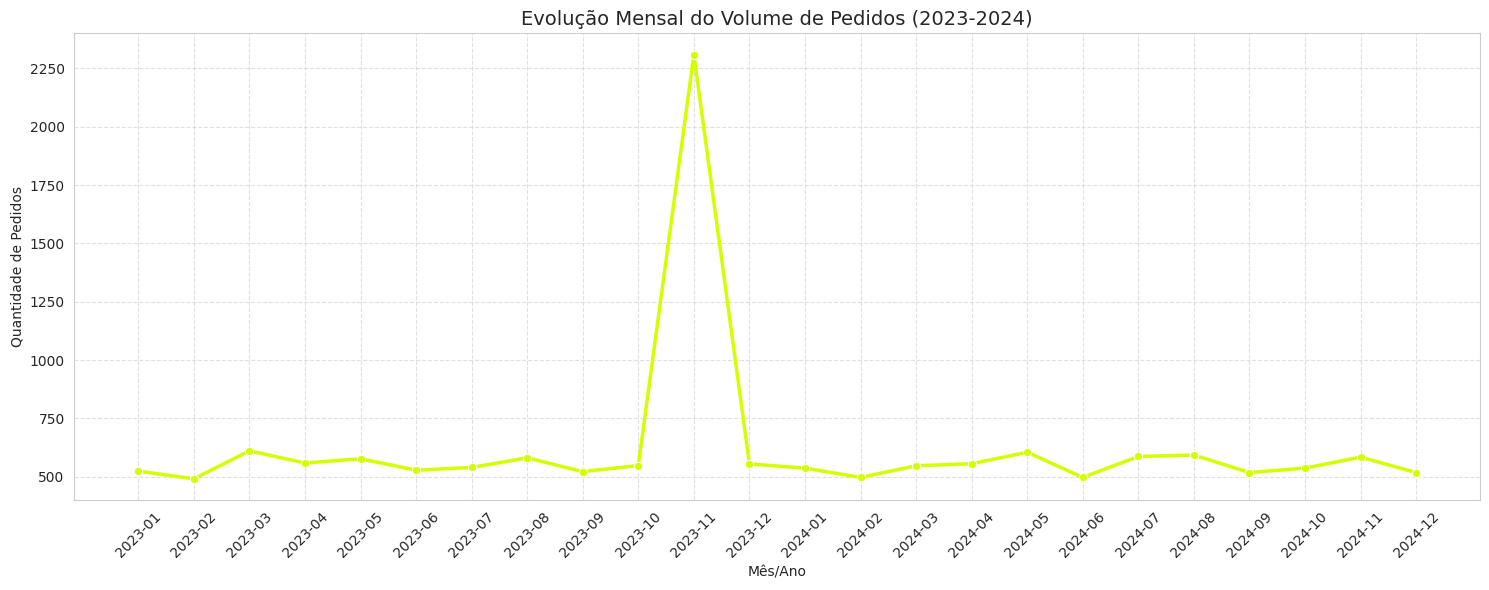

In [12]:
# so garantindo que a data esta no formato correto e criar uma coluna de Ano-Mês, alem de agrupar por mes e contar o volume de pedidos
pedidos['data_pedido'] = pd.to_datetime(pedidos['data_pedido'])
pedidos['mes_ano'] = pedidos['data_pedido'].dt.to_period('M')
sazonalidade = pedidos.groupby('mes_ano').size().reset_index(name='qtd_pedidos')
sazonalidade['mes_ano'] = sazonalidade['mes_ano'].astype(str) #

plt.figure(figsize=(15, 6))
sns.lineplot(data=sazonalidade, x='mes_ano', y='qtd_pedidos', marker='o', color='#D4FF00', linewidth=2.5)

plt.xticks(rotation=45)
plt.title('Evolução Mensal do Volume de Pedidos (2023-2024)', fontsize=14)
plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de Pedidos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Questão 4: Análise de Sazonalidade (2023-2024)

O gráfico de evolução mensal revela um padrão de consumo estável, interrompido por um outlier estatístico significativo.

### **Principais Insights e Hipóteses**

Pico em Novembro de 2023: O volume de pedidos saltou de uma média de ~550 para mais de 2.300 pedidos.

*Hipótese:* Sucesso agressivo da campanha de Black Friday. A NovaShop provavelmente concentrou seus investimentos em marketing e cupons de desconto neste período.

**Estabilidade Operacional:** Fora o mês de novembro, a empresa mantém uma linha de base constante (baseline) entre 500 e 600 pedidos mensais. Isso indica uma demanda recorrente previsível, mas com pouco crescimento orgânico mês a mês.

**Quedas Sazonais:** Observei vales em fevereiro e junho.

Hipótese: Períodos de entressafra comercial ou impacto de feriados prolongados (Carnaval/Festas Juninas) que podem desviar o foco do consumo no e-commerce da NovaShop.

**Ausência de Pico em 2024:** É importante notar que os dados de 2024 (se a base for histórica completa) não mostram o mesmo salto em novembro.

*Hipótese:* Se os dados de 2024 forem parciais ou se a estratégia de Black Friday não foi repetida, isso explica a diferença.

Taxa de Cancelamento por Canal:


,Canal,Taxa de Cancelamento (%)
0,paid_search,30.749682
1,indicacao,12.424575
2,organico,11.794159
3,redes_sociais,11.722296



Principais Motivos de Suporte (Pedidos Falhos):


,Motivo,Quantidade
0,dúvida,353
1,cobrança,272
2,troca,235
3,defeito,109


/tmp/ipykernel_3895/1479725539.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa_canal, x='Taxa de Cancelamento (%)', y='Canal', palette='Reds_r')
/tmp/ipykernel_3895/1479725539.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=motivos_suporte.head(5), x='Quantidade', y='Motivo', palette='Oranges_r')


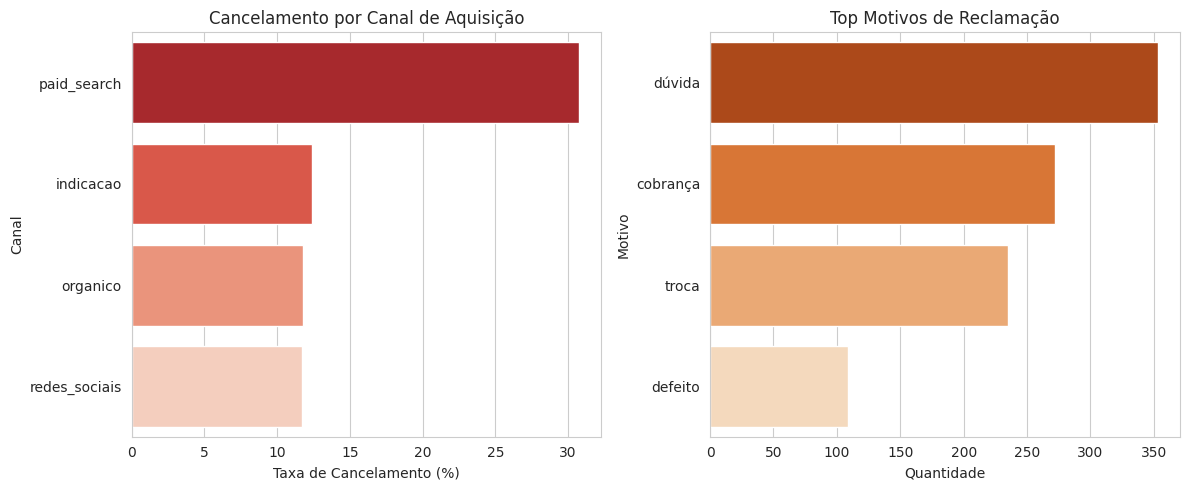

In [13]:

df_problemas = pd.merge(pedidos, clientes, left_on='cliente_id', right_on='id', how='left')
df_problemas = pd.merge(df_problemas, tickets_suporte, left_on='id_x', right_on='pedido_id', how='left', suffixes=('_pedido', '_suporte'))
# filtrei apenas pedidos que nao foram entregues (ou seja, cancelados/devolvidos) e renomeei os ids das tabelas para evitar confusao
pedidos_renomeado = pedidos.rename(columns={'id': 'pedido_id'})
clientes_renomeado = clientes.rename(columns={'id': 'cliente_id_original'})
df_merge_1 = pd.merge(pedidos_renomeado, clientes_renomeado, left_on='cliente_id', right_on='cliente_id_original', how='left')
df_problemas = pd.merge(df_merge_1, tickets_suporte, on='pedido_id', how='left', suffixes=('_pedido', '_suporte'))
# filtrei apenas falhas (ou seja, cancelado/devolvido)
df_falhas = df_problemas[df_problemas['status_pedido'].isin(['cancelado', 'devolvido'])]

# isso aqui eh para analisar a taxa de cancelamento por canal de aquisicao e identificar os motivos (categoria_problema) mais comuns no suporte para esses casos
taxa_canal = df_problemas.groupby('canal_aquisicao')['status_pedido'].value_counts(normalize=True).unstack()['cancelado'] * 100
taxa_canal = taxa_canal.sort_values(ascending=False).reset_index()
taxa_canal.columns = ['Canal', 'Taxa de Cancelamento (%)']
motivos_suporte = df_falhas['categoria_problema'].value_counts().reset_index()
motivos_suporte.columns = ['Motivo', 'Quantidade']

print("Taxa de Cancelamento por Canal:")
display(taxa_canal)
print("\nPrincipais Motivos de Suporte (Pedidos Falhos):")
display(motivos_suporte)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=taxa_canal, x='Taxa de Cancelamento (%)', y='Canal', palette='Reds_r')
plt.title('Cancelamento por Canal de Aquisição')
plt.subplot(1, 2, 2)
sns.barplot(data=motivos_suporte.head(5), x='Quantidade', y='Motivo', palette='Oranges_r')
plt.title('Top Motivos de Reclamação')
plt.tight_layout()
plt.show()

# Questão 5: Análise de Causa Raiz e Canais de Aquisição

A investigação sobre a perda de receita revela uma falha crítica na eficiência do investimento em marketing e no suporte ao cliente.

### **Principais Insights**

**Ineficiência no Tráfego Pago:** O canal de Paid Search apresenta uma taxa de cancelamento alarmante. Isso indica que os anúncios podem estar gerando expectativas erradas ou atraindo um público sem fit com o produto.

**Gap de Informação:** O motivo "Dúvida" ser o líder isolado de chamados sugere que a jornada de compra (ou a descrição dos produtos) não é clara o suficiente, levando o cliente a desistir da compra por incerteza.

**Atrito Financeiro:** O alto volume de chamados por "Cobrança" indica problemas no checkout ou na clareza das faturas, o que gera desconfiança e cancelamentos preventivos.

# Questão 6: Identificação e Tratamento de Inconsistências

A etapa de auditoria e saneamento de dados garantiu a integridade das métricas apresentadas. Abaixo, detalho os achados e as ações corretivas:

### **Relatório de Qualidade (Data Quality)**

**Valores Ausentes:** Identifiquei 79 pedidos sem valor total. Estes registros foram isolados para não impactar negativamente o cálculo do ticket médio e da receita por produto.

**Integridade de Identificadores:** Não foram encontradas duplicidades de IDs nas tabelas de Pedidos e Clientes, confirmando a unicidade dos registros.

**Consistência de Valores:** Não foram detectados preços negativos ou nulos nas tabelas de Produtos e Itens, indicando que a base de catálogo está saudável.

### **Tratamentos de Engenharia de Dados**

**Saneamento de Encoding:** Corrigimos falhas de codificação (ex: de orgÃ¢nico para orgânico), o que permitiu o agrupamento correto dos canais de aquisição.

**Padronização Semântica:** Todos os campos de texto foram convertidos para letras minúsculas (lowercase) e espaços extras foram removidos (strip), eliminando duplicidades lógicas.

**Tipagem Temporal:** As colunas de data foram convertidas para o padrão datetime64[ns], essencial para a precisão do gráfico de sazonalidade da Questão 4.

#